In [1]:
# !pip install -U langchain
# !pip install langchain langchain-community ollama
# !pip install -U langchain langchain-community langchain-core

In [2]:
# pip show langchain

Build a basic agent

In [3]:
from langchain_community.chat_models import ChatOllama

# Your tool
def get_weather(city: str) -> str:
    return f"It's always sunny in {city}!"

# Model
llm = ChatOllama(model="llama3:latest")

# Simple manual agent logic
def agent(user_input: str):
    if "weather" in user_input.lower():
        # extract city (very basic)
        city = user_input.split()[-1]
        return get_weather(city)
    
    return llm.invoke(user_input)

# Run
print(agent("what is the weather in sf"))

It's always sunny in sf!


C:\Users\USER\AppData\Local\Temp\ipykernel_6668\4002277855.py:8: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  llm = ChatOllama(model="llama3:latest")


In [4]:
from langchain_community.chat_models import ChatOllama

llm = ChatOllama(model="llama3:latest")

def get_weather(city: str) -> str:
    return f"It's always sunny in {city}!"

def agent(user_input: str):
    prompt = f"""
You are an assistant.

If the user asks about weather, respond EXACTLY like:
TOOL: get_weather(city)

Otherwise respond normally.

User: {user_input}
"""

    response = llm.invoke(prompt).content

    if "TOOL:" in response:
        city = response.split("(")[-1].replace(")", "")
        return get_weather(city)

    return response

print(agent("what is the weather in sf"))

It's always sunny in sf!


In [5]:
from dataclasses import dataclass
from langchain_community.chat_models import ChatOllama

# ---- TOOLS ----

def get_weather_for_location(city: str) -> str:
    return f"It's always sunny in {city}! ☀️"


@dataclass
class Context:
    user_id: str


def get_user_location(context: Context) -> str:
    user_id = context.user_id
    return "Florida" if user_id == "1" else "SF"


# ---- MODEL ----
llm = ChatOllama(model="llama3:latest")


# ---- SYSTEM PROMPT ----
SYSTEM_PROMPT = """You are an expert weather forecaster, who speaks in puns.

You have access to two tools:
- get_weather_for_location(city)
- get_user_location()

If you need a tool, respond EXACTLY like:
TOOL: tool_name(argument)

Examples:
TOOL: get_user_location()
TOOL: get_weather_for_location(london)
"""


# ---- AGENT LOOP ----
def agent(user_input: str, context: Context):
    prompt = SYSTEM_PROMPT + f"\nUser: {user_input}"

    response = llm.invoke(prompt).content
    print("LLM:", response)

    # ---- TOOL HANDLING ----
    if "TOOL:" in response:
        tool_call = response.split("TOOL:")[1].strip()

        # ---- TOOL 1 ----
        if "get_user_location" in tool_call:
            location = get_user_location(context)
            return agent(f"My location is {location}. What's the weather?", context)

        # ---- TOOL 2 ----
        elif "get_weather_for_location" in tool_call:
            city = tool_call.split("(")[-1].replace(")", "").strip()
            return get_weather_for_location(city)

    return response


# ---- RUN ----
ctx = Context(user_id="1")

print(agent("what's the weather like?", ctx))

LLM: I'm "fair" to say that I can help with that! TOOL: get_user_location()
LLM: A sunny disposition in Florida, eh?

TOOL: get_weather_for_location(Florida)
It's always sunny in Florida! ☀️


In [6]:
from langchain_community.chat_models import ChatOllama

model = ChatOllama(
    model="llama3:latest",
    temperature=0.5
)

response = model.invoke("Tell me a short joke about weather")
print(response.content)

Why did the meteorologist quit his job?

Because he couldn't forecast his future!


In [7]:
from dataclasses import dataclass
import json
from langchain_community.chat_models import ChatOllama

# ---- Schema ----
@dataclass
class ResponseFormat:
    punny_response: str
    weather_conditions: str | None = None


# ---- Model ----
llm = ChatOllama(model="llama3:latest")


# ---- Prompt ----
PROMPT = """
You are an expert weather forecaster who speaks in puns.

Respond ONLY in valid JSON format like this:
{{
  "punny_response": "your pun here",
  "weather_conditions": "optional weather info"
}}

User: {input}
"""


# ---- Function ----
def get_response(user_input: str) -> ResponseFormat:
    response = llm.invoke(PROMPT.format(input=user_input)).content
    print("RAW:", response)

    try:
        data = json.loads(response)
        return ResponseFormat(**data)
    except Exception:
        # fallback if model messes up JSON
        return ResponseFormat(
            punny_response=response,
            weather_conditions=None
        )


# ---- Run ----
result = get_response("What's the weather in SF?")
print(result)

RAW: {
  "punny_response": "San Francisco's forecast is 'groggy' with fog, but it'll 'shine' up later!",
  "weather_conditions": "Partly cloudy with a high of 58°F and a low of 48°F. Foggy mornings will give way to partly sunny skies in the afternoon."
}
ResponseFormat(punny_response="San Francisco's forecast is 'groggy' with fog, but it'll 'shine' up later!", weather_conditions='Partly cloudy with a high of 58°F and a low of 48°F. Foggy mornings will give way to partly sunny skies in the afternoon.')


Add memory

In [8]:
# !pip install langgraph

In [9]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langchain_community.chat_models import ChatOllama

# ---- 1. MODEL ----
llm = ChatOllama(model="llama3:latest")

# ---- 2. MEMORY ----
memory = InMemorySaver()

# ---- 3. STATE SCHEMA ----
class State(TypedDict):
    messages: List[dict]

# ---- 4. NODE FUNCTION ----
def chatbot(state: State):
    messages = state["messages"]

    # Call LLM
    response = llm.invoke(messages).content

    # Return NEW state (important!)
    return {
        "messages": messages + [
            {"role": "assistant", "content": response}
        ]
    }

# ---- 5. BUILD GRAPH ----
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.set_entry_point("chatbot")
builder.set_finish_point("chatbot")

graph = builder.compile(checkpointer=memory)

# ---- 6. CONFIG (session id) ----
config = {"configurable": {"thread_id": "user1"}}

# ---- 7. RUN ----

# First message
result1 = graph.invoke(
    {"messages": [{"role": "user", "content": "Hello"}]},
    config
)
print("AI:", result1["messages"][-1]["content"])

# Second message (memory works here)
result2 = graph.invoke(
    {"messages": [{"role": "user", "content": "What did I say earlier?"}]},
    config
)
print("AI:", result2["messages"][-1]["content"])

AI: Hello! It's nice to meet you. Is there something I can help you with, or would you like to chat?
AI: This conversation just started, so you haven't said anything yet! I'm happy to chat with you, though. What's on your mind?


overview

In [12]:
from dataclasses import dataclass
from typing import Optional

from langchain_community.chat_models import ChatOllama

# ---- SYSTEM PROMPT ----
SYSTEM_PROMPT = """You are an expert weather forecaster, who speaks in puns.

You have access to tools:

- get_weather_for_location(city)
- get_user_location()

If user asks weather:
1. Find location
2. Then answer

Respond in JSON:
{
  "punny_response": "...",
  "weather_conditions": "..."
}
"""

# ---- CONTEXT ----
@dataclass
class Context:
    user_id: str

# ---- RESPONSE FORMAT ----
@dataclass
class ResponseFormat:
    punny_response: str
    weather_conditions: Optional[str] = None

# ---- TOOLS ----
def get_weather_for_location(city: str) -> str:
    return f"It's always sunny in {city}!"

def get_user_location(context: Context) -> str:
    return "Florida" if context.user_id == "1" else "SF"

# ---- MODEL (OLLAMA QWEN) ----
model = ChatOllama(
    model="qwen3.5",
    temperature=0,
    num_predict=200
)

# ---- SIMPLE MEMORY ----
memory = {}

# ---- AGENT (MANUAL REPLACEMENT) ----
def agent_invoke(messages, context: Context, thread_id="1"):
    state = memory.get(thread_id, [])

    # add system once
    if not state:
        state.append({"role": "system", "content": SYSTEM_PROMPT})

    state.extend(messages)

    # ---- STEP 1: get location ----
    if "weather" in messages[-1]["content"].lower():
        location = get_user_location(context)
        weather = get_weather_for_location(location)

        prompt = f"""
User asked weather.

Location: {location}
Weather: {weather}

Respond in JSON with pun.
"""

        response = model.invoke(prompt).content

        result = ResponseFormat(
            punny_response=response,
            weather_conditions=weather
        )

        state.append({"role": "assistant", "content": response})
        memory[thread_id] = state

        return {"structured_response": result}

    # ---- NORMAL RESPONSE ----
    response = model.invoke(messages[-1]["content"]).content

    result = ResponseFormat(
        punny_response=response,
        weather_conditions=None
    )

    state.append({"role": "assistant", "content": response})
    memory[thread_id] = state

    return {"structured_response": result}


# ---- RUN ----
config = {"configurable": {"thread_id": "1"}}

response = agent_invoke(
    [{"role": "user", "content": "what is the weather outside?"}],
    context=Context(user_id="1"),
    thread_id="1"
)

print(response["structured_response"])


response = agent_invoke(
    [{"role": "user", "content": "thank you!"}],
    context=Context(user_id="1"),
    thread_id="1"
)

print(response["structured_response"])

ResponseFormat(punny_response='', weather_conditions="It's always sunny in Florida!")
ResponseFormat(punny_response="You're very welcome! 😊 If you need anything else—whether it's help with a task, a question, or just a chat—feel free to ask anytime. Have a wonderful day! 🌟", weather_conditions=None)


Agents

Agents combine language models with tools to create systems that can reason about tasks, decide which tools to use, and iteratively work towards solutions.


Core components
Model


In [ ]:
from langchain_community.chat_models import ChatOllama
from langchain.agents import create_agent

llm = ChatOllama(model="llama3")

agent = create_agent(
    llm,
    tools=tools
)

In [7]:
!pip install --upgrade --force-reinstall langchain langchain-community langchain-ollama

  Using cached langchain-1.2.15-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_ollama-1.1.0-py3-none-any.whl.metadata (3.0 kB)
     ---------------------------------------- 0.0/108.8 kB ? eta -:--:--
     ---------------------- ---------------- 61.4/108.8 kB 1.7 MB/s eta 0:00:01
     -------------------------------------- 108.8/108.8 kB 1.6 MB/s eta 0:00:00
  Using cached sqlalchemy-2.0.49-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
  Using cached aiohttp-3.13.5-cp311-cp311-win_amd64.whl.metadata (8.4 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metada

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'g:\\langchain\\.langchain_venv\\lib\\site-packages\\81d243bd2c585b0f4821__mypyc.cp311-win_amd64.pyd'
Check the permissions.


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3:latest",
    temperature=0,
    # other params...
)

In [12]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to French. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = llm.invoke(messages)
ai_msg

AIMessage(content='Je adore le programmation.\n\n(Note: "programmation" is the feminine form of the noun in French, but if you want to use the masculine form, it would be "le programme" instead.)', additional_kwargs={}, response_metadata={'model': 'llama3:latest', 'created_at': '2026-04-20T17:44:24.5842742Z', 'done': True, 'done_reason': 'stop', 'total_duration': 34408396700, 'load_duration': 12453525800, 'prompt_eval_count': 35, 'prompt_eval_duration': 4856230900, 'eval_count': 43, 'eval_duration': 16998010900, 'logprobs': None, 'model_name': 'llama3:latest', 'model_provider': 'ollama'}, id='lc_run--019dabfd-cc9c-7641-b98c-b76ad88100f0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 35, 'output_tokens': 43, 'total_tokens': 78})

In [13]:
print(ai_msg.content)

Je adore le programmation.

(Note: "programmation" is the feminine form of the noun in French, but if you want to use the masculine form, it would be "le programme" instead.)


Tool calling

In [15]:
from typing import List

from langchain.messages import AIMessage
from langchain.tools import tool
from langchain_ollama import ChatOllama


@tool
def validate_user(user_id: int, addresses: List[str]) -> bool:
    """Validate user using historical addresses.

    Args:
        user_id (int): the user ID.
        addresses (List[str]): Previous addresses as a list of strings.
    """
    return True


llm = ChatOllama(
    model="gpt-oss:20b",
    validate_model_on_init=True,
    temperature=0,
).bind_tools([validate_user])

result = llm.invoke(
    "Could you validate user 123? They previously lived at "
    "123 Fake St in Boston MA and 234 Pretend Boulevard in "
    "Houston TX."
)

if isinstance(result, AIMessage) and result.tool_calls:
    print(result.tool_calls)

[{'name': 'validate_user', 'args': {'user_id': 123, 'addresses': ['123 Fake St in Boston MA', '234 Pretend Boulevard in Houston TX']}, 'id': 'e242679d-557e-4809-bf95-655041717bb7', 'type': 'tool_call'}]


Multi-modal

In [14]:
!pip install pillow

   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.1 MB 487.6 kB/s eta 0:00:15
    --------------------------------------- 0.1/7.1 MB 1.0 MB/s eta 0:00:07
   - -------------------------------------- 0.2/7.1 MB 1.3 MB/s eta 0:00:06
   - -------------------------------------- 0.3/7.1 MB 1.6 MB/s eta 0:00:05
   --- ------------------------------------ 0.6/7.1 MB 2.4 MB/s eta 0:00:03
   ---- ----------------------------------- 0.8/7.1 MB 2.7 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/7.1 MB 3.1 MB/s eta 0:00:02
   ------- -------------------------------- 1.4/7.1 MB 3.7 MB/s eta 0:00:02
   --------- ------------------------------ 1.7/7.1 MB 4.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.0/7.1 MB 4.3 MB/s eta 0:00:02
   ------------ ---------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



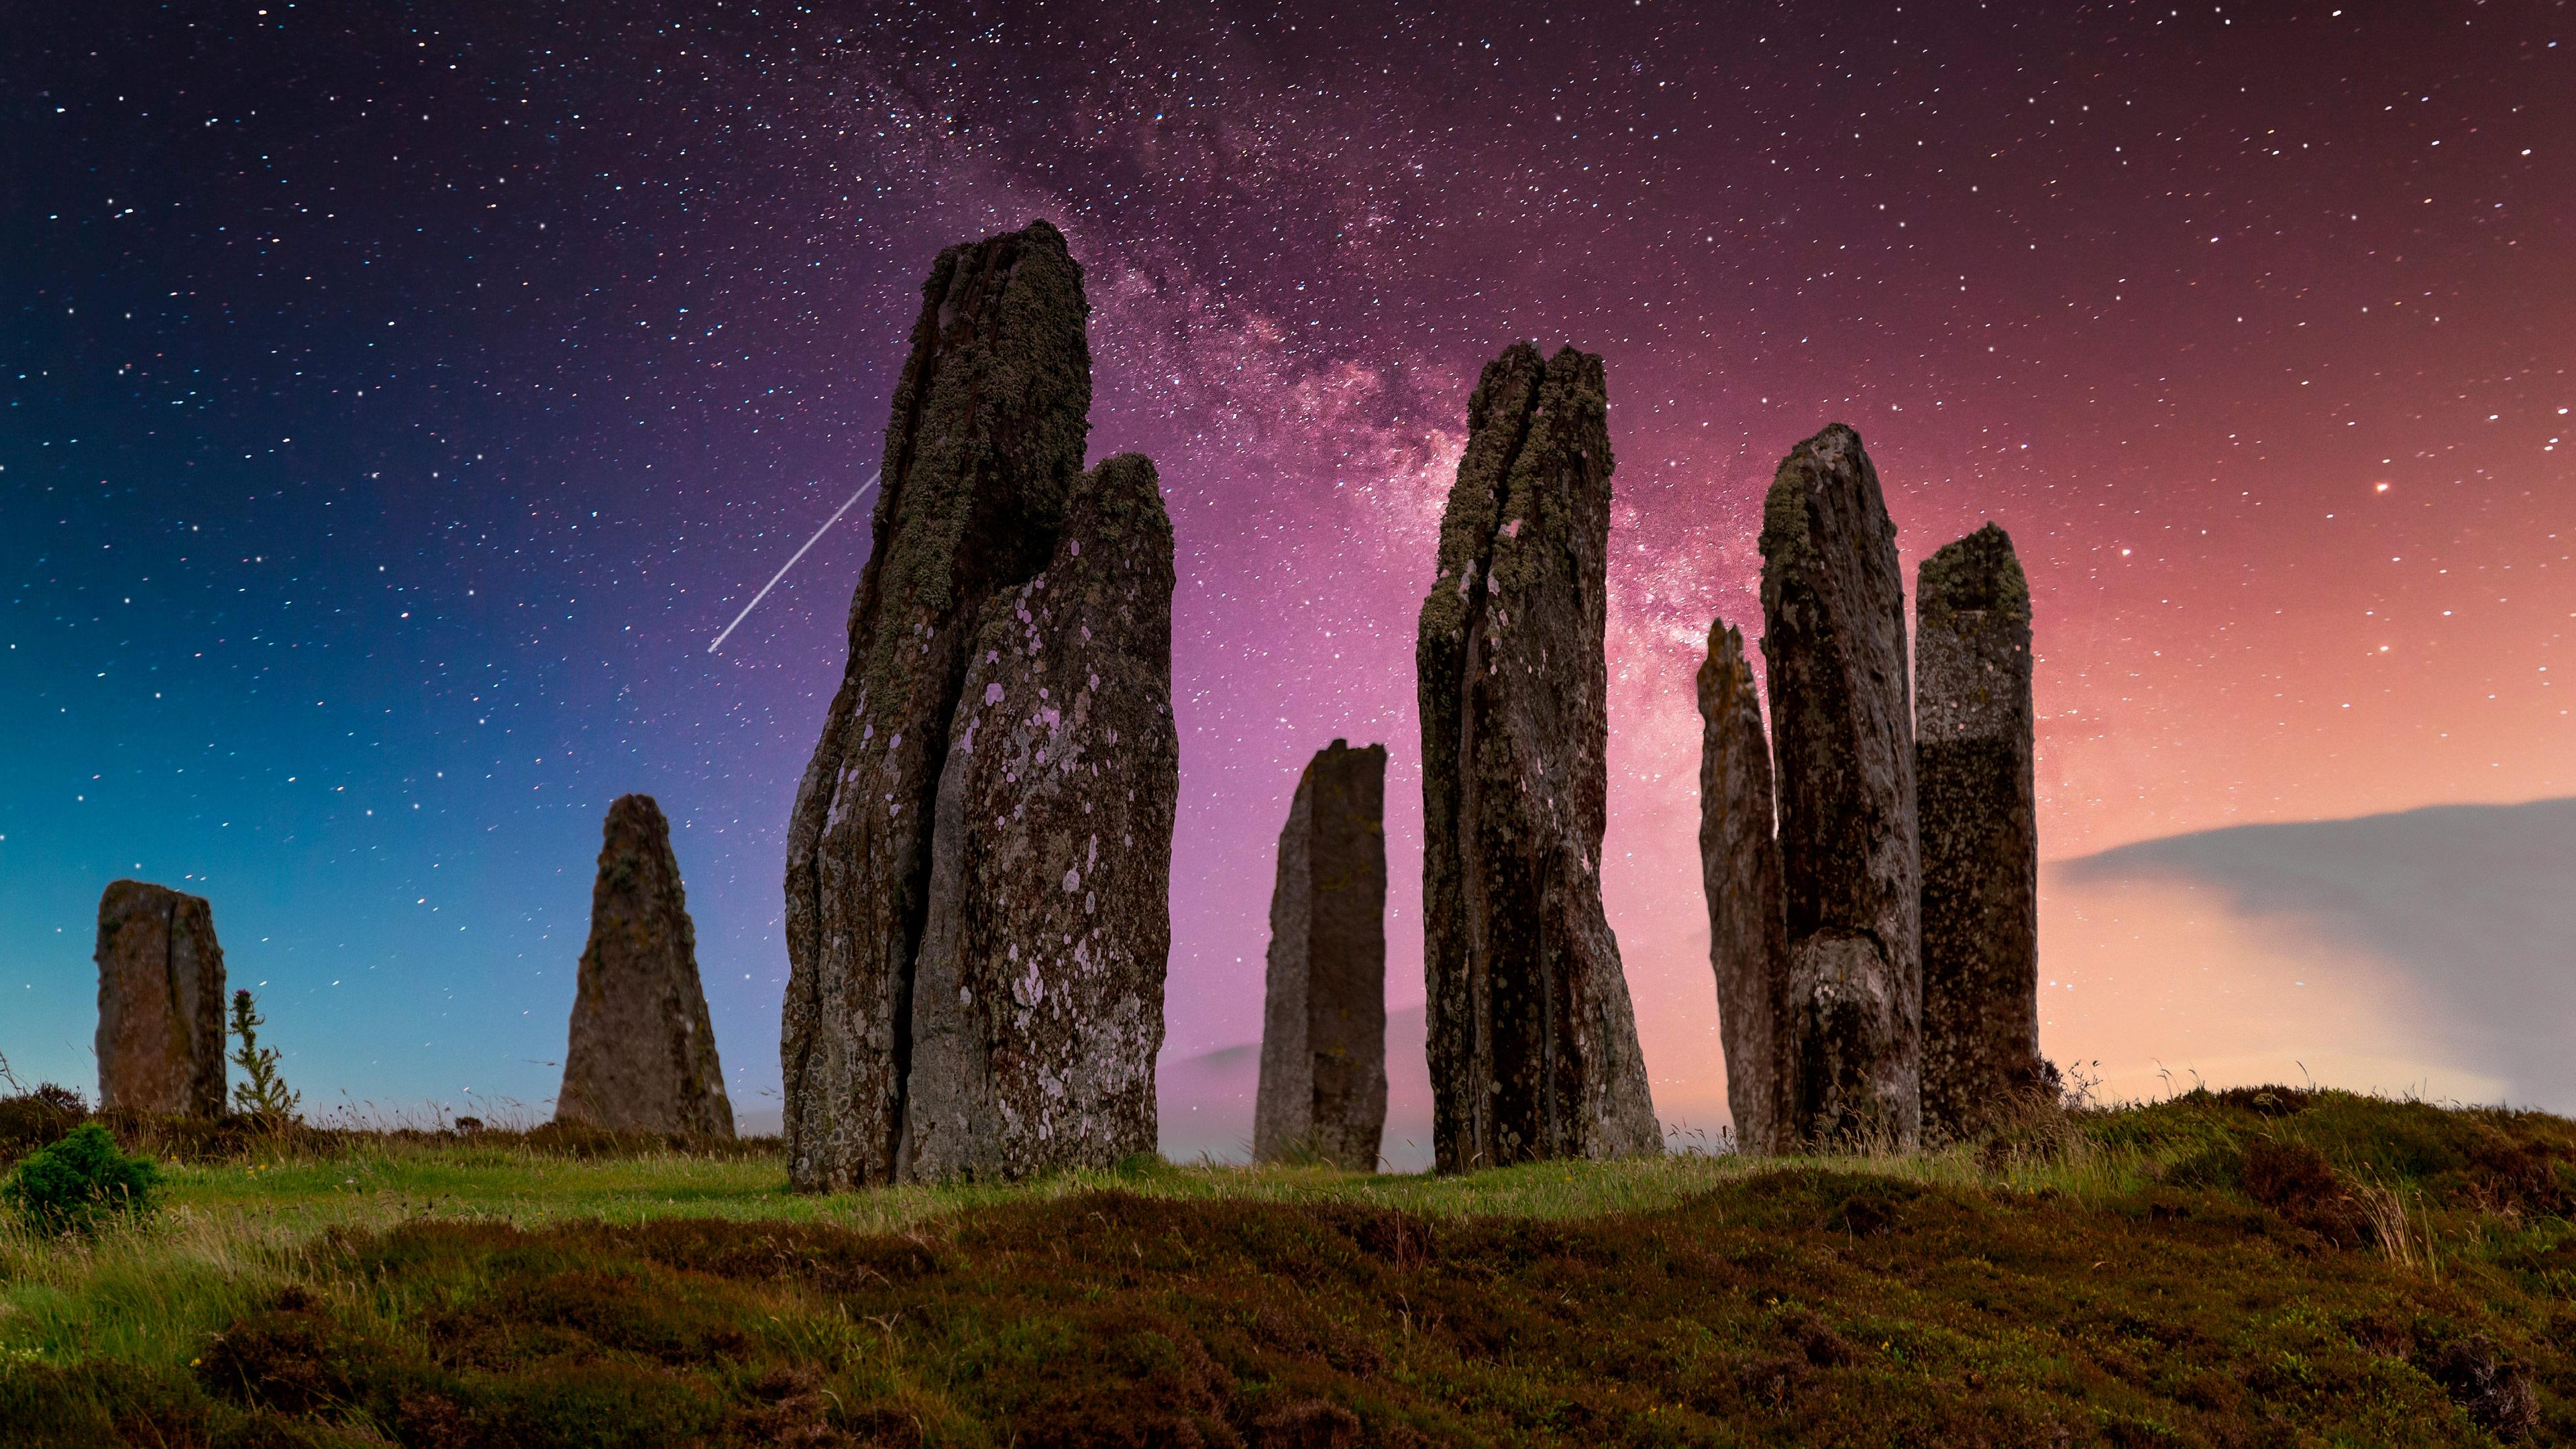

In [17]:
import base64
from io import BytesIO

from IPython.display import HTML, display
from PIL import Image


def convert_to_base64(pil_image):
    """
    Convert PIL images to Base64 encoded strings

    :param pil_image: PIL image
    :return: Re-sized Base64 string
    """

    buffered = BytesIO()
    pil_image.save(buffered, format="JPEG")  # You can change the format if needed
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str


def plt_img_base64(img_base64):
    """
    Disply base64 encoded string as image

    :param img_base64:  Base64 string
    """
    # Create an HTML img tag with the base64 string as the source
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'
    # Display the image by rendering the HTML
    display(HTML(image_html))


file_path = "134191456109591189.jpg"
pil_image = Image.open(file_path)

image_b64 = convert_to_base64(pil_image)
plt_img_base64(image_b64)

In [18]:
from langchain.messages import HumanMessage
from langchain_ollama import ChatOllama

llm = ChatOllama(model="bakllava", temperature=0)


def prompt_func(data):
    text = data["text"]
    image = data["image"]

    image_part = {
        "type": "image_url",
        "image_url": f"data:image/jpeg;base64,{image}",
    }

    content_parts = []

    text_part = {"type": "text", "text": text}

    content_parts.append(image_part)
    content_parts.append(text_part)

    return [HumanMessage(content=content_parts)]


from langchain_core.output_parsers import StrOutputParser

chain = prompt_func | llm | StrOutputParser()

query_chain = chain.invoke(
    {"text": "What is the Dollar-based gross retention rate?", "image": image_b64}
)

print(query_chain)

100%


Log probabilities

In [ ]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1", logprobs=True)

response = llm.invoke("What color is the sky?")
logprobs = response.response_metadata["logprobs"]
for entry in logprobs[:5]:
    print(f"Token: {entry['token']!r:>15}  logprob: {entry['logprob']:.4f}")

Top-K alternatives per token

llm = ChatOllama(model="llama3.1", logprobs=True, top_logprobs=3)

response = llm.invoke("The capital of France is")
logprobs = response.response_metadata["logprobs"]
for entry in logprobs[:3]:
    print(f"Chosen: {entry['token']!r}")
    if entry.get("top_logprobs"):
        for alt in entry["top_logprobs"]:
            print(f"    {alt['token']!r:>12}  logprob: {alt['logprob']:.4f}")

Reasoning models and custom message roles

from langchain.messages import HumanMessage
from langchain_core.messages import ChatMessage
from langchain_ollama import ChatOllama

llm = ChatOllama(model="granite3.2:8b")

messages = [
    ChatMessage(role="control", content="thinking"),
    HumanMessage("What is 3^3?"),
]

response = llm.invoke(messages)
print(response.content)

Langchain BaseStore

In [2]:
from langchain_core.stores import BaseStore
from typing import List, Tuple, Optional, Iterator

class InMemoryStore(BaseStore[str, str]):
    def __init__(self):
        self.store = {}

    def mget(self, keys: List[str]) -> List[Optional[str]]:
        return [self.store.get(k) for k in keys]

    def mset(self, key_value_pairs: List[Tuple[str, str]]) -> None:
        for key, value in key_value_pairs:
            self.store[key] = value

    def mdelete(self, keys: List[str]) -> None:
        for key in keys:
            self.store.pop(key, None)

    def yield_keys(self, prefix: Optional[str] = None) -> Iterator[str]:
        for key in self.store:
            if prefix is None or key.startswith(prefix):
                yield key

In [3]:
store = InMemoryStore()

store.mset([("a", "1"), ("b", "2")])

print(store.mget(["a", "b", "c"]))
# ['1', '2', None]

store.mdelete(["b"])

print(list(store.yield_keys()))
# ['a']

['1', '2', None]
['a']
